In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [10]:
from langgraph.graph import StateGraph
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.schema import SystemMessage, HumanMessage
from IPython.display import Image, display
from typing import Dict, List

In [4]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [5]:
class CourseDesignState(Dict):
    subject_area: str
    module_options: List[str]
    module_analysis: Dict[str, str]
    best_module: str

In [25]:
from pydantic import BaseModel, Field
from typing import List
from langchain_core.output_parsers import JsonOutputParser
from langchain.prompts import PromptTemplate

# Define structure for a single course module
class CourseModule(BaseModel):
    title: str = Field(description="The title of the course module")
    description: str = Field(description="A brief description of the course module")

# Define structure for the full module list
class ModuleList(BaseModel):
    modules: List[CourseModule]

In [ ]:
# # Create the output parser
# parser = JsonOutputParser(pydantic_object=ModuleList)

# # Define the prompt template with format instructions
# prompt_template = PromptTemplate(
#     template="""
#     You are an academic course designer.
    
#     Design a new university course for the subject area: {subject_area}
    
#     Suggest three main course modules. Each module must include:
#     - A title
#     - A brief description including foundational concepts, practicle applications and emerging trends.

#     Respond strictly in JSON format as specified below:
#     {format_instructions}
#     """,
#     input_variables=["subject_area"],
#     partial_variables={"format_instructions": parser.get_format_instructions()}
# )


In [61]:
def generate_module_options(state: CourseDesignState) -> CourseDesignState:

    #Create the output parser
    parser = JsonOutputParser(pydantic_object=ModuleList)

    # Define the prompt template with format instructions
    prompt_template = PromptTemplate(
        template="""
        You are an academic course designer.
        
        Design a new university course for the subject area: {subject_area}
        
        Suggest three main course modules. Each module must include:
        - A title
        - A brief description including foundational concepts, practicle applications and emerging trends.

        Respond strictly in JSON format as specified below:
        {format_instructions}
        """,
        input_variables=["subject_area"],
        partial_variables={"format_instructions": parser.get_format_instructions()}
    )   

    # Build the final chain: prompt -> model -> parser
    chain = prompt_template | llm | parser

    # Invoke the chain with the current subject area
    result: ModuleList = chain.invoke({"subject_area": state["subject_area"]})

    # Store raw structured module objects, not just formatted strings
    state["module_options"] = [module for module in result["modules"]]
    return state


In [55]:
def analyze_module(state: CourseDesignState) -> CourseDesignState:
    module_analysis = {}

    for module in state["module_options"]:
        title = module["title"]
        description = module["description"]

        prompt = f"""
        Analyze the following course module:
        Title: {title}
        Description: {description}

        Evaluate it based on:
        - Expected learning outcomes
        - Relevance to industry
        - Engagement potential for students

        Provide a structured analysis.
        """
        response = llm.invoke([
            SystemMessage(content="You are a university curriculum analyst."),
            HumanMessage(content=prompt)
        ])
        module_analysis[title] = {
            "description": description,
            "analysis": response.content
        }

    state["module_analysis"] = module_analysis
    return state


In [57]:
def select_best_module(state: CourseDesignState) -> CourseDesignState:
    # Format the module data into a readable structured string
    analysis_input = "\n\n".join(
        f"Title: {title}\nDescription: {data['description']}\nAnalysis: {data['analysis']}"
        for title, data in state["module_analysis"].items()
    )

    prompt = f"""
    Given the following course modules and their evaluations:

    {analysis_input}

    Rank these modules based on:
    - Impact on student development
    - Future career relevance
    - Overall course value

    Select the best module and justify your selection.
    """

    response = llm.invoke([
        SystemMessage(content="You are a higher education strategist."),
        HumanMessage(content=prompt)
    ])

    state["best_module"] = response.content
    return state


In [58]:
workflow = StateGraph(CourseDesignState)

workflow.add_node("generate_module_options", generate_module_options)
workflow.add_node("analyze_module", analyze_module)
workflow.add_node("select_best_module", select_best_module)

workflow.set_entry_point("generate_module_options")

workflow.add_edge("generate_module_options", "analyze_module")
workflow.add_edge("analyze_module", "select_best_module")

graph = workflow.compile()

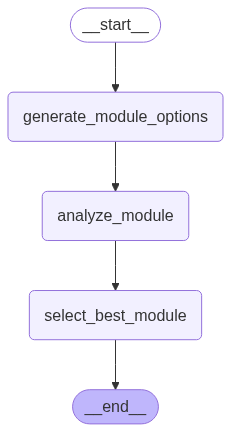

In [59]:

display(Image(graph.get_graph().draw_mermaid_png()))


In [60]:
input_data = {
    "subject_area": "Artificial Intelligence in Healthcare"
}

result = graph.invoke(input_data)
print("AI-Generated Course Modules:\n", result["module_options"])
print("\nModule Analysis:\n", result["module_analysis"])
print("\nBest Module Selected:\n", result["best_module"])

AI-Generated Course Modules:
 [{'title': 'Foundations of AI in Healthcare: Data, Ethics, and Core Concepts', 'description': 'This module introduces the fundamental concepts of Artificial Intelligence and Machine Learning specifically tailored for the healthcare domain. Foundational concepts include an overview of various AI/ML paradigms (e.g., supervised, unsupervised, deep learning), an in-depth look at diverse healthcare data types (Electronic Health Records, medical imaging, genomic data, wearable sensor data), and critical discussions on data privacy, security (e.g., HIPAA, GDPR), and ethical considerations (e.g., bias, fairness, transparency) inherent in AI applications. Practical applications will focus on data acquisition, pre-processing, and basic predictive modeling, demonstrating how raw healthcare data is transformed into actionable insights. Emerging trends covered include federated learning for privacy-preserving data analysis, synthetic data generation, and the increasing